# Model C Development (Logistic Regression)

## 1. Setup

In [3]:
import pandas as pd
import os
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score,
    classification_report
)

## 2. Data Loading

In [4]:
input_path = Path("../data/processed/dataset_final.csv")
df = pd.read_csv(input_path)
print("Data loaded. Shape:", df.shape)
display(df.head())

Data loaded. Shape: (1200, 41)


,transaction_type_online purchase,transaction_type_transfer,transaction_type_withdrawal,merchant_category_Clothing,merchant_category_Crypto,merchant_category_Electronics,merchant_category_Entertainment,merchant_category_Food,merchant_category_Gambling,merchant_category_Services,...,account_age_days,description_risk_score,transaction_frequency_24h,num_failed_transactions_7d,transaction_hour,is_weekend,num_devices_used,num_countries_used,kyc_verified,is_fraud
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.929790,-0.368841,0.0,0.0,8.0,0.0,2.0,0.0,0.0,0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.761706,-0.368841,0.0,0.0,7.0,0.0,2.0,0.0,1.0,0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.964482,-0.368841,0.0,0.0,19.0,0.0,1.0,0.0,0.0,1
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.560900,3.310755,0.0,0.0,3.0,0.0,1.0,1.0,1.0,1
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.064750,-0.368841,0.0,0.0,10.0,0.0,2.0,0.0,0.0,0


## 3. Data Preparation

In [ ]:
# 1. Feature Selection / Dropping Irrelevant Columns
# These columns are typically dropped if present, but may already be absent
# in the preprocessed 'dataset_final.csv'.
cols_to_drop = [
    'transaction_id', 'timestamp', 'customer_id',
    'transaction_description','customer_support_note'
 ]
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

# 2. Encoding Categorical Variables
# Assuming one-hot encoding has already been applied upstream to create dataset_final.csv.
# If not, a step like the following would be needed:
# df_encoded = pd.get_dummies(df_clean, drop_first=True)
# For this notebook, df_clean is already df_encoded as per dataset_final.csv structure.
X_features = df_clean.copy() # Use df_clean as the basis for features

In [6]:
# 3. Split X (Features) and y (Target)
X = X_features.drop('is_fraud', axis=1) # Drop the target from the features
y = df['is_fraud']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (960, 40)
Testing set shape: (240, 40)


## 4. Model Training

In [8]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


## 5. Model Evaluation

In [9]:
y_pred = knn_model.predict(X_test)
y_prob = knn_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8333
ROC-AUC: 0.7313

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.96      0.90       188
           1       0.73      0.37      0.49        52

    accuracy                           0.83       240
   macro avg       0.79      0.66      0.69       240
weighted avg       0.82      0.83      0.81       240



## 6. Save Results

In [11]:
model_name = "K Nearest Neighbors"
output_file = "../results/model_d_results.csv"

# Calculate metrics
metrics = {
    'model': model_name,
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob)
}

# Create DataFrame
results_df = pd.DataFrame([metrics])

# Ensure directory exists
os.makedirs(os.path.dirname(output_file), exist_ok=True)

# Save to CSV
results_df.to_csv(output_file, index=False)

print(f"Results for {model_name} saved to {output_file}")

Results for K Nearest Neighbors saved to ../results/model_d_results.csv


Computing permutation importance for the KNN model...
Top 10 features by permutation importance:


,Feature,Importance
0,transaction_hour,0.041528
1,description_risk_score,0.031111
2,time_since_last_transaction_hr,0.009583
3,merchant_category_Food,0.005833
4,semantic_merchant_category_daily essentials,0.003194
5,merchant_category_Services,0.002500
6,transaction_amount,0.001944
7,transaction_frequency_24h,0.001250
8,merchant_category_Clothing,0.001250
9,transaction_type_online purchase,0.000694


Saved permutation importance to '../results/model_d_feature_importance.csv'


C:\Users\mdani\AppData\Local\Temp\ipykernel_41744\989846243.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=perm_df.head(10), palette='viridis')


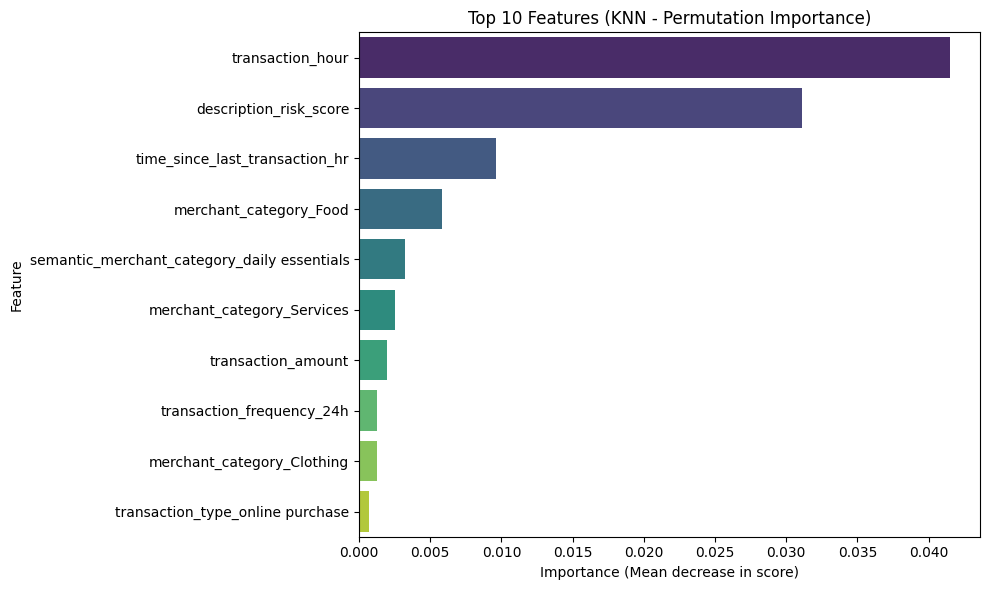

In [13]:
# 6a. Feature Importance (Permutation Importance for KNN model)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

print("Computing permutation importance for the KNN model...")
perm = permutation_importance(knn_model, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm.importances_mean
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Top 10 features by permutation importance:")
display(perm_df.head(10))

# Save to results
os.makedirs('../results', exist_ok=True)
perm_df.to_csv('../results/model_d_feature_importance.csv', index=False)
print("Saved permutation importance to '../results/model_d_feature_importance.csv'")

# Plot top 10
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=perm_df.head(10), palette='viridis')
plt.title('Top 10 Features (KNN - Permutation Importance)')
plt.xlabel('Importance (Mean decrease in score)')
plt.tight_layout()
plt.show()

LLM PROMPT:

The columns of the dataset are as below:
transaction_type_online purchase	transaction_type_transfer	transaction_type_withdrawal	merchant_category_Clothing	merchant_category_Crypto	merchant_category_Electronics	merchant_category_Entertainment	merchant_category_Food	merchant_category_Gambling	merchant_category_Services	...	account_age_days	description_risk_score	transaction_frequency_24h	num_failed_transactions_7d	transaction_hour	is_weekend	num_devices_used	num_countries_used	kyc_verified	is_fraud

All of these are used to train a model to classify for fraud cases to differentiate if it is fraud or not.
After doing feature importance, the results obtained as as below, what can be concluded from the results of the feature importance?:

	Feature	Importance
0	transaction_hour	0.041528
1	description_risk_score	0.031111
2	time_since_last_transaction_hr	0.009583
3	merchant_category_Food	0.005833
4	semantic_merchant_category_daily essentials	0.003194
5	merchant_category_Services	0.002500
6	transaction_amount	0.001944
7	transaction_frequency_24h	0.001250
8	merchant_category_Clothing	0.001250
9	transaction_type_online purchase	0.000694

MODEL RESPONSE:
Top features: transaction_hour (0.0415) and description_risk_score (0.0311).
Other features have much smaller importances (≤ ~0.01), so the KNN model’s behavior is dominated by those first two signals.
What this means 🔍
Permutation importance measures how much the model score drops when a feature is shuffled. Larger values → the model relies more on that feature.
Here, the model relies most on time-of-day patterns (transaction_hour) and the text-derived description_risk_score. The rest of the features provide only marginal additional signal for KNN.
Caveats & checks ⚠️
KNN is sensitive to feature scaling: if features are not standardized, transaction_hour (0–23) could dominate distances artificially. Verify that features were scaled appropriately (StandardScaler/MinMax).
Permutation importance can be biased when features are correlated — importance may be split across correlated features or be misleading.
The absolute values are small overall (especially after the top two), which can indicate the model has modest predictive power or that many features are weak individually